# Titanic Boosting and Model Comparison

This notebook prepares the Titanic data, explores basic correlations, and compares baseline logistic regression, Lasso-selected logistic regression, Gradient Boosting, and XGBoost on the same validation split.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

## Data Loading and Exploration

The next cells load the Titanic training dataset from the provided URL, then visualize correlations among the numeric variables before the 70/30 train-validation split.

In [2]:
train_data = pd.read_csv('https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/train.csv')

## Feature Preparation

This block separates the target variable, prepares the Titanic features, removes less useful columns, creates dummy variables, and scales the final inputs before the 70/30 train-validation split.

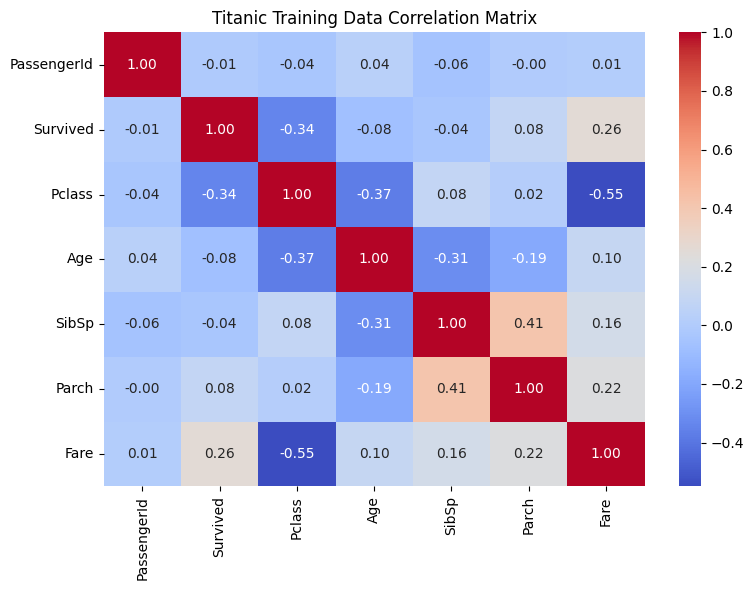

In [3]:
correlation_data = train_data.select_dtypes(include="number")
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Titanic Training Data Correlation Matrix")
plt.tight_layout()

## Logistic Regression Baseline and Lasso Selection

We first fit a baseline logistic regression using all prepared variables. Then we use an L1-penalized logistic model to identify the most relevant variables and compare performance after feature selection.

In [4]:
y_train = train_data["Survived"]
train_data.drop(labels="Survived", axis=1, inplace=True)

## Gradient Boosting Search and Evaluation

This section tests several learning rates for Gradient Boosting, then fits a selected configuration and summarizes its validation performance with a classification report and a visual confusion matrix.

In [5]:
full_data = train_data.copy()

## XGBoost Evaluation

The final section imports XGBoost, trains an XGBoost classifier on the same data split, and presents its validation metrics and confusion matrix for comparison with the earlier models.

In [6]:
drop_columns = ["Name", "Age", "SibSp", "Ticket", "Cabin", "Parch", "Embarked"]
full_data.drop(labels=drop_columns, axis=1, inplace=True)

In [7]:
full_data = pd.get_dummies(full_data, columns=["Sex"])
full_data.fillna(value=0.0, inplace=True)
feature_names = full_data.columns.tolist()

In [8]:
X_train = full_data.values
X_test = full_data.values.copy()

In [9]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
state = 12  
test_size = 0.30  
  
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=state)

## Model Variable Selection

Use the next cell to control which variables are passed to every model in the notebook. Leave `selected_feature_names = None` to use all variables, or provide a custom list to restrict the models to a subset.

In [11]:
available_features = pd.DataFrame({"Available Variables": feature_names})
selected_feature_names = None
# Example: selected_feature_names = ["Pclass", "Fare", "Sex_female"]

if selected_feature_names is None:
    model_feature_names = feature_names.copy()
else:
    missing_features = sorted(set(selected_feature_names) - set(feature_names))
    if missing_features:
        raise ValueError(f"These variables are not available: {missing_features}")
    model_feature_names = selected_feature_names.copy()

model_mask = [feature in model_feature_names for feature in feature_names]
X_train_model = X_train[:, model_mask]
X_val_model = X_val[:, model_mask]
X_test_model = X_test[:, model_mask]

display(available_features)
display(pd.DataFrame({"Variables Used By All Models": model_feature_names}))

,Available Variables
0,PassengerId
1,Pclass
2,Fare
3,Sex_female
4,Sex_male


,Variables Used By All Models
0,PassengerId
1,Pclass
2,Fare
3,Sex_female
4,Sex_male


In [12]:
baseline_logit = LogisticRegression(max_iter=1000, random_state=0)
baseline_logit.fit(X_train_model, y_train)
baseline_predictions = baseline_logit.predict(X_val_model)

lasso_selector = LogisticRegressionCV(
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="accuracy",
    max_iter=1000,
    random_state=0,
)
lasso_selector.fit(X_train_model, y_train)

lasso_selected_mask = lasso_selector.coef_.ravel() != 0
selected_features = [feature for feature, keep in zip(model_feature_names, lasso_selected_mask) if keep]

if not selected_features:
    selected_features = model_feature_names.copy()
    lasso_selected_mask = [True] * len(model_feature_names)

X_train_lasso = X_train_model[:, lasso_selected_mask]
X_val_lasso = X_val_model[:, lasso_selected_mask]

lasso_logit = LogisticRegression(max_iter=1000, random_state=0)
lasso_logit.fit(X_train_lasso, y_train)
lasso_predictions = lasso_logit.predict(X_val_lasso)

,Model,Validation Accuracy,Variables Used
0,Baseline Logit,0.757,5
1,Logit After Lasso Selection,0.757,3


,Selected Variables
0,Pclass
1,Sex_female
2,Sex_male


,Variable,Lasso Coefficient,Selected By Lasso
3,Sex_female,1.0279,True
1,Pclass,-0.6614,True
4,Sex_male,-0.7623,True
0,PassengerId,0.0000,False
2,Fare,0.0000,False


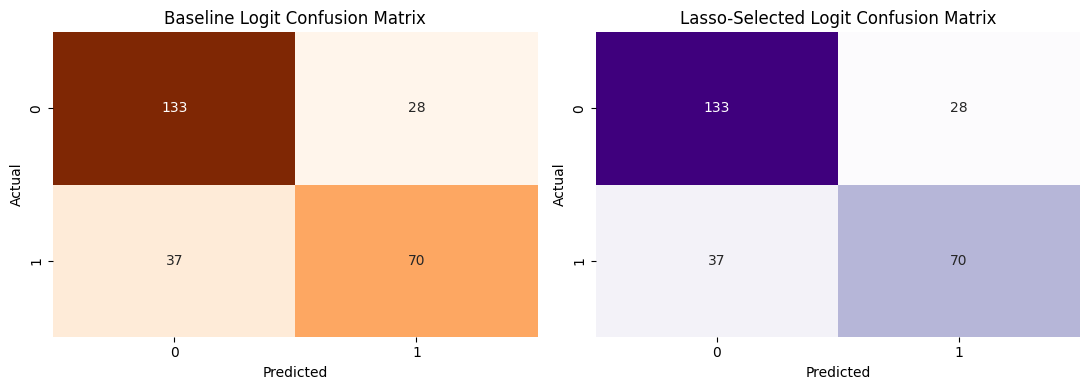

In [13]:
logit_comparison = pd.DataFrame(
    {
        "Model": ["Baseline Logit", "Logit After Lasso Selection"],
        "Validation Accuracy": [
            round(baseline_logit.score(X_val_model, y_val), 3),
            round(lasso_logit.score(X_val_lasso, y_val), 3),
        ],
        "Variables Used": [len(model_feature_names), len(selected_features)],
    }
)

selected_features_table = pd.DataFrame({"Selected Variables": selected_features})
lasso_coefficients = pd.DataFrame(
    {
        "Variable": model_feature_names,
        "Lasso Coefficient": lasso_selector.coef_.ravel(),
        "Selected By Lasso": lasso_selected_mask,
    }
).sort_values(["Selected By Lasso", "Lasso Coefficient"], ascending=[False, False])

display(logit_comparison)
display(selected_features_table)
display(lasso_coefficients.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(confusion_matrix(y_val, baseline_predictions), annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[0])
axes[0].set_title("Baseline Logit Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_val, lasso_predictions), annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[1])
axes[1].set_title("Lasso-Selected Logit Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

In [14]:
lr_list = [0.05, 0.075, 0.1, 0.25, 0.5, 0.75, 1]

for learning_rate in lr_list:
    gb_clf = GradientBoostingClassifier(n_estimators=20, learning_rate=learning_rate, max_features=2, max_depth=2, random_state=0)
    gb_clf.fit(X_train_model, y_train)

    print("Learning rate: ", learning_rate)
    print("Accuracy score (training): {0:.3f}".format(gb_clf.score(X_train_model, y_train)))
    print("Accuracy score (validation): {0:.3f}".format(gb_clf.score(X_val_model, y_val)))

Learning rate:  0.05
Accuracy score (training): 0.801
Accuracy score (validation): 0.731
Learning rate:  0.075
Accuracy score (training): 0.814
Accuracy score (validation): 0.731
Learning rate:  0.1
Accuracy score (training): 0.812
Accuracy score (validation): 0.724
Learning rate:  0.25
Accuracy score (training): 0.835
Accuracy score (validation): 0.750
Learning rate:  0.5
Accuracy score (training): 0.864
Accuracy score (validation): 0.772
Learning rate:  0.75
Accuracy score (training): 0.875
Accuracy score (validation): 0.754
Learning rate:  1
Accuracy score (training): 0.875
Accuracy score (validation): 0.739


,Model,Validation Accuracy
0,Gradient Boosting Classifier,0.772


,precision,recall,f1-score,support
0,0.772,0.882,0.823,161.000
1,0.774,0.607,0.681,107.000
accuracy,0.772,0.772,0.772,0.772
macro avg,0.773,0.745,0.752,268.000
weighted avg,0.773,0.772,0.766,268.000


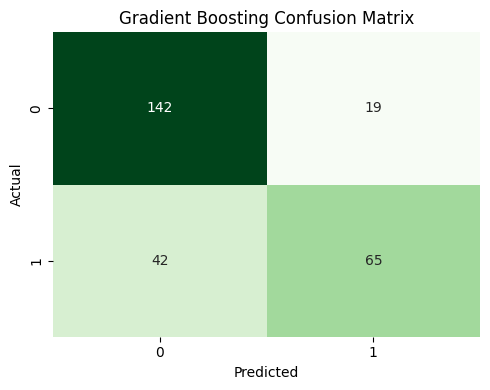

In [15]:
gb_clf2 = GradientBoostingClassifier(n_estimators=20, learning_rate=0.5, max_features=2, max_depth=2, random_state=0)
gb_clf2.fit(X_train_model, y_train)
predictions = gb_clf2.predict(X_val_model)

gb_score = gb_clf2.score(X_val_model, y_val)
gb_report = pd.DataFrame(classification_report(y_val, predictions, output_dict=True)).transpose()
gb_confusion = confusion_matrix(y_val, predictions)

summary = pd.DataFrame(
    {
        "Model": ["Gradient Boosting Classifier"],
        "Validation Accuracy": [round(gb_score, 3)],
    }
)

display(summary)
display(gb_report.round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(gb_confusion, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

In [16]:
import subprocess
import sys

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

In [17]:
xgb_clf = XGBClassifier(eval_metric="logloss", random_state=0)
_ = xgb_clf.fit(X_train_model, y_train)
xgb_predictions = xgb_clf.predict(X_val_model)

,Model,Validation Accuracy
0,XGBoost Classifier,0.739


,precision,recall,f1-score,support
0,0.763,0.820,0.790,161.000
1,0.695,0.617,0.653,107.000
accuracy,0.739,0.739,0.739,0.739
macro avg,0.729,0.718,0.722,268.000
weighted avg,0.736,0.739,0.736,268.000


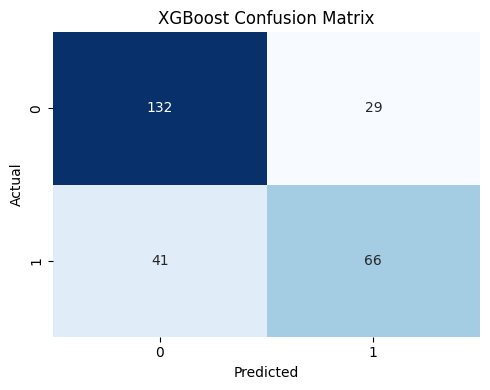

In [18]:
xgb_score = xgb_clf.score(X_val_model, y_val)
xgb_report = pd.DataFrame(classification_report(y_val, xgb_predictions, output_dict=True)).transpose()
xgb_confusion = confusion_matrix(y_val, xgb_predictions)

summary = pd.DataFrame(
    {
        "Model": ["XGBoost Classifier"],
        "Validation Accuracy": [round(xgb_score, 3)],
    }
)

display(summary)
display(xgb_report.round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(xgb_confusion, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

## Random Forest Evaluation

This final section fits a Random Forest classifier on the same validation split so its performance can be compared directly against the logistic, Gradient Boosting, and XGBoost models.

,Model,Validation Accuracy
0,Random Forest Classifier,0.78


,precision,recall,f1-score,support
0,0.777,0.888,0.829,161.00
1,0.786,0.617,0.691,107.00
accuracy,0.780,0.780,0.780,0.78
macro avg,0.781,0.753,0.760,268.00
weighted avg,0.781,0.780,0.774,268.00


,Feature,Importance
4,Sex_male,0.352
3,Sex_female,0.310
1,Pclass,0.145
2,Fare,0.144
0,PassengerId,0.049


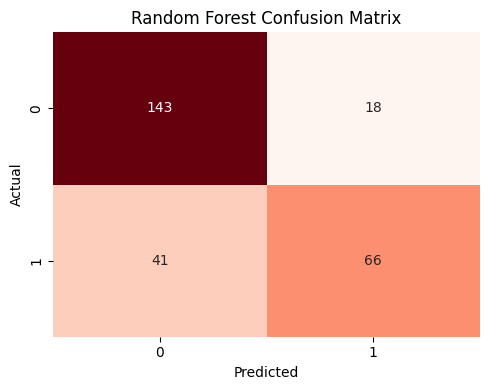

In [19]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0)
rf_clf.fit(X_train_model, y_train)
rf_predictions = rf_clf.predict(X_val_model)

rf_score = rf_clf.score(X_val_model, y_val)
rf_report = pd.DataFrame(classification_report(y_val, rf_predictions, output_dict=True)).transpose()
rf_confusion = confusion_matrix(y_val, rf_predictions)
rf_importance = pd.DataFrame(
    {
        "Feature": model_feature_names,
        "Importance": rf_clf.feature_importances_,
    }
).sort_values("Importance", ascending=False)

summary = pd.DataFrame(
    {
        "Model": ["Random Forest Classifier"],
        "Validation Accuracy": [round(rf_score, 3)],
    }
)

display(summary)
display(rf_report.round(3))
display(rf_importance.round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(rf_confusion, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()